In [2]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

import utility_functions as uf

import warnings
warnings.simplefilter("ignore", FutureWarning)

# Distribution

In [3]:
df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").drop_duplicates()

In [4]:
df_global.columns

Index(['subfield_id', 'counts_all', 'counts_individual', 'counts_collab',
       'probability_all', 'probability_individual', 'probability_collab',
       'counts_individual_pct', 'counts_collab_pct', 'year'],
      dtype='object')

In [5]:
df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").drop_duplicates()
df_gl_sf = df_global.pivot(index="year", columns="subfield_id", values="counts_individual")
df_gl_prob = df_global.pivot(index="year", columns="subfield_id", values="probability_individual")

In [6]:
df_gl_sf = (
    df_global.pivot(index="year", columns="subfield_id", values="counts_individual")
    .T
    .merge(uf.df_topics[["subfield_id", "domain_id"]].drop_duplicates(), left_index=True, right_on="subfield_id", how="left")
    .sort_values(["domain_id", "subfield_id"])
    .drop(columns="domain_id")
    .set_index("subfield_id")
    .T
)
df_gl_prob = df_gl_sf.div(df_gl_sf.sum(axis=1), axis=0)


In [6]:
uf.df_topics[["subfield_id", "domain_id"]].pivot(columns="domain_id", values="subfield_id")

domain_id,1,2,3,4
0,NaN,NaN,1908.0,NaN
1,NaN,NaN,3107.0,NaN
2,NaN,1408.0,NaN,NaN
3,1111.0,NaN,NaN,NaN
4,NaN,NaN,2309.0,NaN
...,...,...,...,...
4511,NaN,1207.0,NaN,NaN
4512,NaN,1202.0,NaN,NaN
4513,NaN,NaN,1710.0,NaN
4514,NaN,3322.0,NaN,NaN


In [209]:
domain_subfield = uf.df_topics[["subfield_id", "domain_id"]].drop_duplicates().pivot(columns="domain_id", values="subfield_id")
domain_subfield_dict = {}
for domain in domain_subfield.columns:
    domain_subfield_dict[domain] = domain_subfield[domain].dropna().astype(int).to_list()

(0.0, 0.02)

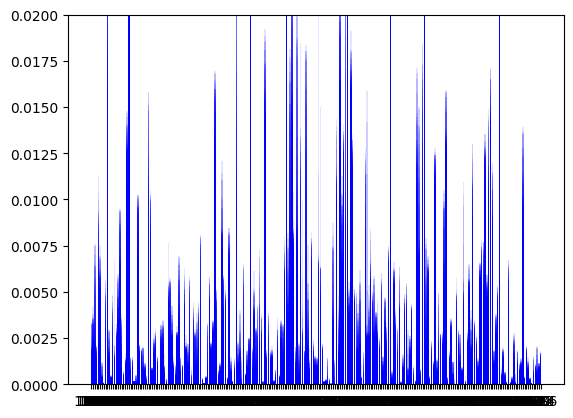

In [178]:
start_year = 1970
end_year = 2023
for year_loop in range(start_year, end_year+1):
    plt.bar(df_gl_prob.columns.astype(str), df_gl_prob.loc[year_loop], alpha=0.1, color="blue")
plt.ylim(0, 0.02)

Domain 1: 325.2570720506451


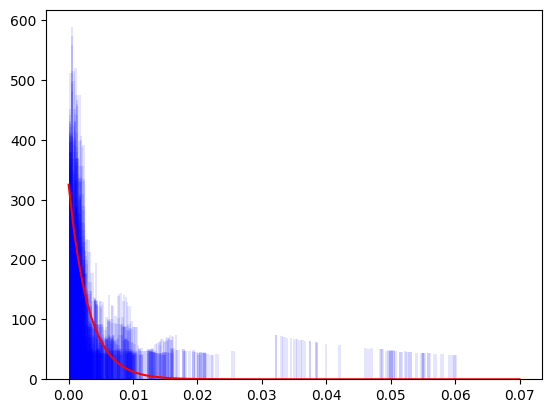

In [181]:
start_year = 1970
end_year = 2023

domain_id = 1
subfield_id_list = uf.df_topics[["subfield_id", "domain_id"]].drop_duplicates().query("domain_id == @domain_id").subfield_id.to_list()

for year_loop in range(start_year, end_year+1):
    plt.hist(df_gl_prob.loc[year_loop, subfield_id_list], bins=100, alpha=0.1, color="blue", density=True)
    data = df_gl_prob.loc[year_loop, subfield_id_list].values

scale = stats.expon.fit(data, floc=0)[1]  # scale parameter
lambda_hat = 1 / scale
print(f"Domain {domain_id}: {lambda_hat}")

x = np.linspace(0, 0.07, 100)
plt.plot(x, lambda_hat*np.exp(-lambda_hat * x), color="red")
# plt.ylim(0, 0.02)


In [92]:
data = df_gl_prob.loc[start_year:end_year].fillna(0)

0.7466274755073943 0 0.004970617077919681


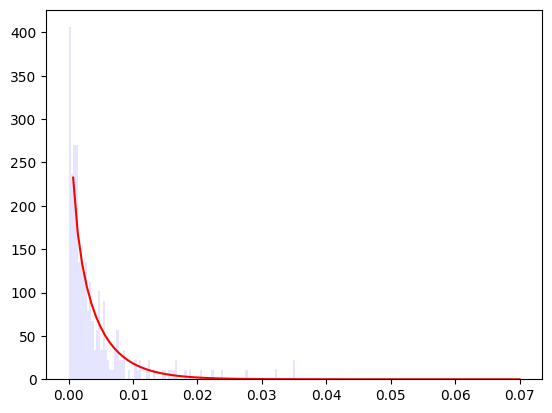

KstestResult(statistic=np.float64(0.09758804247730901), pvalue=np.float64(0.5529908661930901), statistic_location=np.float64(0.0025487061202565), statistic_sign=np.int8(1))

In [ ]:
domain_id = 4
subfield_id_list = uf.df_topics[["subfield_id", "domain_id"]].drop_duplicates().query("domain_id == @domain_id").subfield_id.to_list()

data = df_gl_prob.loc[year_loop, subfield_id_list]
alpha, loc, theta = stats.gamma.fit(data, floc=0)
print(alpha, loc, theta)

plt.hist(df_gl_prob.loc[year_loop], bins=100, alpha=0.1, color="blue", density=True)
plt.plot(x, stats.gamma.pdf(x, a=alpha, scale=theta), color="red")
plt.show()

stats.kstest(data, 'gamma', args=(alpha, 0, theta))

KstestResult(statistic=np.float64(0.11811317514502484), pvalue=np.float64(0.0016079712168226266), statistic_location=np.float64(0.0014071850611393), statistic_sign=np.int8(1))

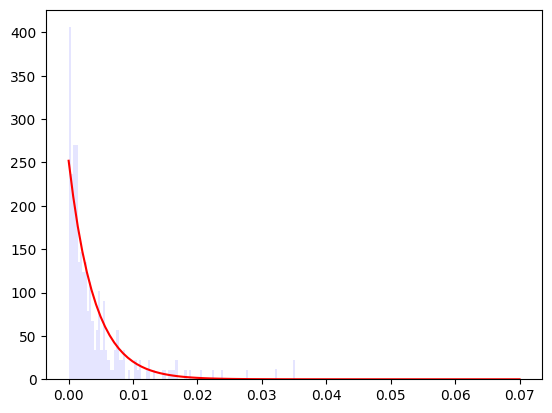

In [99]:
start_year = 2023
end_year = 2023
for year_loop in range(start_year, end_year+1):
    plt.hist(df_gl_prob.loc[year_loop], bins=100, alpha=0.1, color="blue", density=True)

data = df_gl_prob.loc[year_loop].fillna(0).values
loc, scale = stats.expon.fit(data, floc=0)

lambda_hat = 1 / scale
# print(f"Domain {domain_id}: {lambda_hat}")

x = np.linspace(0, 0.07, 100)
plt.plot(x, lambda_hat*np.exp(-lambda_hat * x), color="red")
stats.kstest(data, 'expon', args=(loc, scale))
# plt.ylim(0, 0.02)

In [45]:
param = "field_id"
df_gl_f = (
    df_gl_sf
    .T
    .merge(uf.df_topics[["subfield_id", param]], left_index=True, right_on="subfield_id", how="left")
    .drop(columns="subfield_id")
    .groupby(param)
    .sum()
    .T
)
df_gl_f_prob = df_gl_f.div(df_gl_f.sum(axis=1), axis=0)

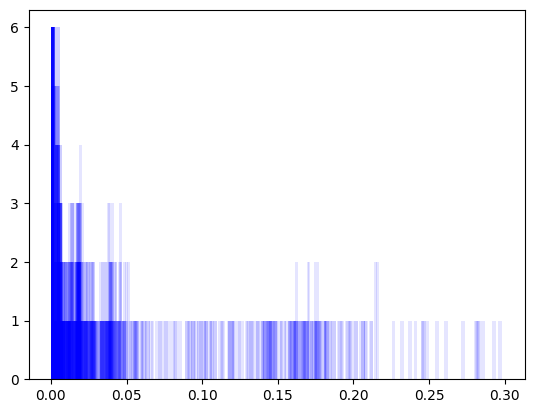

In [ ]:
start_year = 1970
end_year = 2023

for year_loop in range(start_year, end_year+1):
    plt.hist(df_gl_f_prob.loc[year_loop], bins=100, alpha=0.1, color="blue")
# plt.ylim(0, 0.02)

In [50]:
param = "domain_id"
df_gl_d = (
    df_gl_sf
    .T
    .merge(uf.df_topics[["subfield_id", param]], left_index=True, right_on="subfield_id", how="left")
    .drop(columns="subfield_id")
    .groupby(param)
    .sum()
    .T
)
df_gl_d_prob = df_gl_d.div(df_gl_d.sum(axis=1), axis=0)

In [133]:
df_gl_d_prob

domain_id,1,2,3,4
1970,0.250381,0.279756,0.341269,0.128594
1971,0.271325,0.224798,0.370779,0.133098
1972,0.272343,0.219210,0.372490,0.135957
1973,0.275010,0.222229,0.361680,0.141081
1974,0.273441,0.224086,0.360388,0.142085
1975,0.265612,0.232476,0.361601,0.140311
1976,0.258439,0.238339,0.359789,0.143433
1977,0.259523,0.247143,0.348719,0.144615
1978,0.262777,0.238738,0.347621,0.150864
1979,0.257901,0.242022,0.351692,0.148385


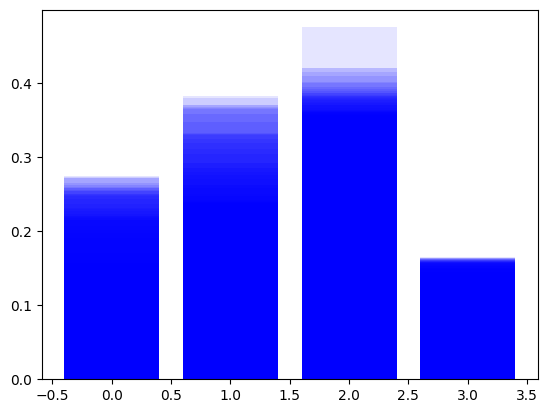

In [127]:
start_year = 1970
end_year = 2023
for year_loop in range(start_year, end_year+1):
    plt.bar(np.arange(4), df_gl_d_prob.loc[year_loop], alpha=0.1, color="blue")
# plt.ylim(0, 0.02)

In [245]:
df_gl_d_prob.loc[2023]

domain_id
1    0.143332
2    0.364939
3    0.338890
4    0.152839
Name: 2023, dtype: float64

In [313]:
n_total_articles = 5170

domain_intervals = np.concatenate([[0], df_gl_d_prob.mean(axis=0).cumsum()])

sample = np.random.rand(n_total_articles)

In [314]:
domain_samples = pd.cut(sample, domain_intervals, labels=[1, 2, 3, 4])
n_domain_articles = domain_samples.value_counts().to_dict()

In [315]:
n_domain_articles

{1: 1091, 2: 1439, 3: 1874, 4: 766}

<BarContainer object of 4 artists>

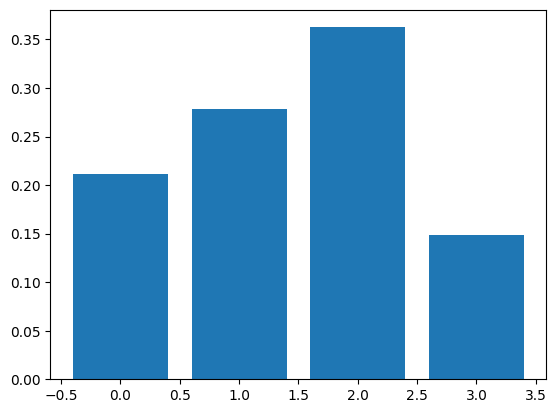

In [316]:
plt.bar(np.arange(4), np.array(list(n_domain_articles.values())) / n_total_articles)

In [317]:
domain_params_dict = {}

for domain in range(1, 5):
    subfield_id_list = (
        uf.df_topics
        [["subfield_id", "domain_id"]]
        .drop_duplicates()
        .query("domain_id == @domain")
        .subfield_id.to_list()
    )
    data = df_gl_prob.loc[year_loop, subfield_id_list]
    alpha, loc, theta = stats.gamma.fit(data, floc=0)
    domain_params_dict[domain] = {
        "alpha": alpha, "loc": loc, "theta": theta
    }

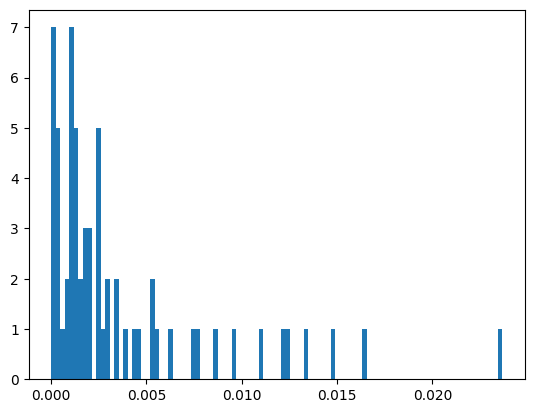

In [318]:
_ = plt.hist(df_gl_prob.loc[year_loop, subfield_id_list], bins=100)

In [319]:
domain_params_dict

{1: {'alpha': 0.6806141519548126,
  'loc': 0,
  'theta': np.float64(0.004517230759114186)},
 2: {'alpha': 0.7507980164527404,
  'loc': 0,
  'theta': np.float64(0.00555672337608307)},
 3: {'alpha': 0.7011557003316345,
  'loc': 0,
  'theta': np.float64(0.00633129912677581)},
 4: {'alpha': 0.7466274755074348,
  'loc': 0,
  'theta': np.float64(0.004970617077919471)}}

In [320]:
sample_dict = {}
sample_articles = []
sample = []
for domain, n_articles in n_domain_articles.items():

    sample_dict[domain] = stats.gamma.rvs(a=domain_params_dict[domain]["alpha"],
                              loc=domain_params_dict[domain]["loc"],
                              scale=domain_params_dict[domain]["theta"],
                              size=len(domain_subfield_dict[domain]))
    sample += list(sample_dict[domain])

    prob_ranges = np.concatenate([[0], (sample_dict[domain] / sample_dict[domain].sum()).cumsum()])
    tmp = pd.cut(np.random.rand(n_domain_articles[domain]), prob_ranges, labels=domain_subfield_dict[domain])
    sample_articles.append(tmp.value_counts())
df_sample_articles = pd.concat(sample_articles)
    # print(sample_dict)

In [321]:
df_test_prob = df_sample_articles.to_frame("counts") / df_sample_articles.sum()

In [322]:
sample_norm = np.array(sample) / np.array(sample).sum()

In [323]:
test_sum = 0
for domain in range(1, 5):
    print(sample_dict[domain].sum())
    test_sum += sample_dict[domain].sum()
print(test_sum)

0.13271268543185066
0.21218608448120277
0.460001136935721
0.25095332052765196
1.0558532273764265


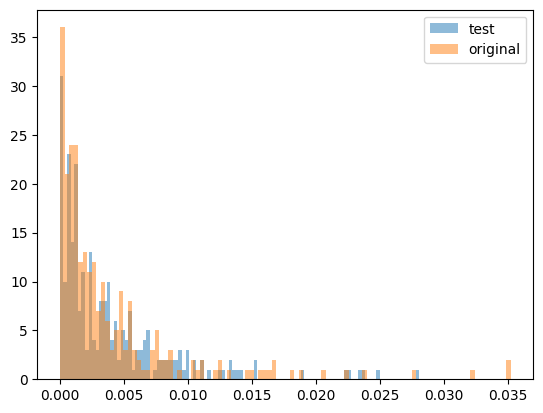

In [325]:
_ = plt.hist(df_test_prob, bins=100, alpha=0.5, label="test")
_ = plt.hist(df_gl_prob.loc[2023], bins=100, alpha=0.5, label="original")
plt.legend()

In [ ]:
import numpy as np
from scipy import stats

# Example data
data1 = df_test_prob
data2 = df_gl_prob.loc[2023]

# Two-sample KS test
D, p_value = stats.ks_2samp(data1, data2)

# print("KS statistic:", D)
print("p-value:", p_value)

p-value: 0.5421343001612227


In [327]:
df_cs = pd.read_csv(uf.PATH+"df_country_subfield/individual_2023.csv", index_col=0)

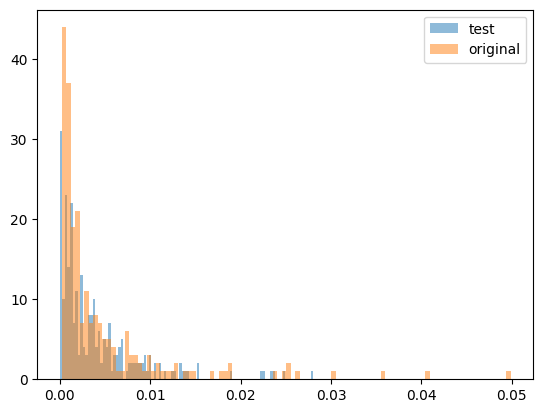

In [331]:
_ = plt.hist(df_test_prob, bins=100, alpha=0.5, label = "test")
_ = plt.hist(df_cs.loc["AE"] / df_cs.loc["AE"].sum(), bins=100, alpha=0.5, label="original")
plt.legend()

In [337]:
(df_cs.loc["AE"] / df_cs.loc["AE"].sum())

1100    0.000580
1102    0.000387
1103    0.000193
1104    0.000580
1105    0.000580
          ...   
3609    0.000580
3611    0.001547
3612    0.000967
3614    0.002128
3616    0.001161
Name: AE, Length: 252, dtype: float64

In [338]:

# Example data
data1 = df_gl_prob.loc[2023]
data2 = (df_cs.loc["AE"] / df_cs.loc["AE"].sum()).to_frame("counts").fillna(0).counts

# Two-sample KS test
D, p_value = stats.ks_2samp(data1, data2)

# print("KS statistic:", D)
print("p-value:", p_value)

p-value: 0.008667286336107877


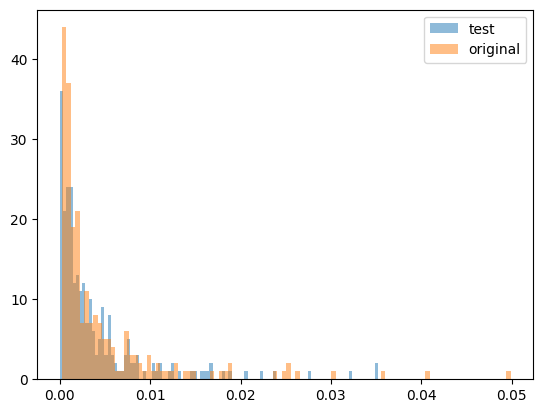

In [ ]:
_ = plt.hist(df_gl_prob.loc[2023], bins=100, alpha=0.5, label = "test")
_ = plt.hist(df_cs.loc["AE"] / df_cs.loc["AE"].sum(), bins=100, alpha=0.5, label="original")
plt.legend()

KstestResult(statistic=np.float64(0.20090568708053352), pvalue=np.float64(2.159085918842893e-09), statistic_location=np.float64(0.0015473887814313346), statistic_sign=np.int8(1))

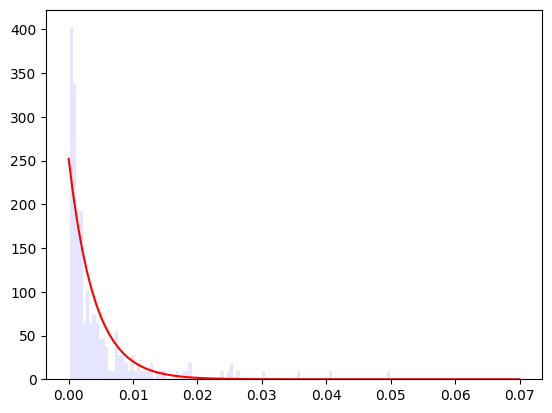

In [341]:
start_year = 2023
end_year = 2023
df_test = df_cs.loc["AE"] / df_cs.loc["AE"].sum()
# for year_loop in range(start_year, end_year+1):
plt.hist(df_test, bins=100, alpha=0.1, color="blue", density=True)

data = df_test.fillna(0).values
loc, scale = stats.expon.fit(data, floc=0)

lambda_hat = 1 / scale
# print(f"Domain {domain_id}: {lambda_hat}")

x = np.linspace(0, 0.07, 100)
plt.plot(x, lambda_hat*np.exp(-lambda_hat * x), color="red")
stats.kstest(data, 'expon', args=(loc, scale))
# plt.ylim(0, 0.02)

FitDataError: Invalid values in `data`.  Maximum likelihood estimation with 'gamma' requires that 0 < (x - loc)/scale  < inf for each x in `data`.

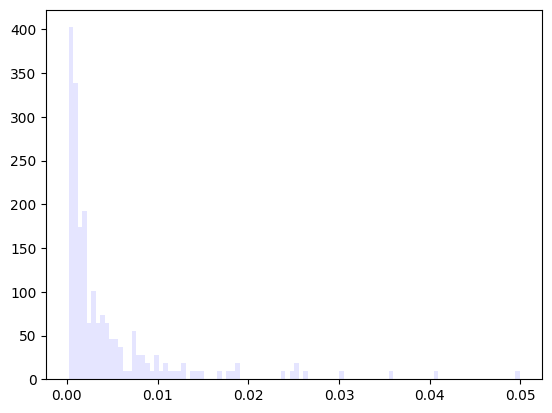

In [342]:
domain_id = 4
subfield_id_list = uf.df_topics[["subfield_id", "domain_id"]].drop_duplicates().query("domain_id == @domain_id").subfield_id.to_list()

plt.hist(df_test, bins=100, alpha=0.1, color="blue", density=True)

data = df_test.fillna(0).values
alpha, loc, theta = stats.gamma.fit(data, floc=0)
print(alpha, loc, theta)

plt.hist(df_gl_prob.loc[year_loop], bins=100, alpha=0.1, color="blue", density=True)
plt.plot(x, stats.gamma.pdf(x, a=alpha, scale=theta), color="red")
plt.show()

stats.kstest(data, 'gamma', args=(alpha, 0, theta))

# Test distance uniform

In [9]:
n_subfields = len(df_gl_sf.columns)

In [10]:
sample = np.random.rand(100)
sample_prob = sample / sample.sum()

In [13]:
df_test = pd.DataFrame({}, columns=df_gl_sf.columns.astype(str))
for i in range(1, n_subfields+1):
    sample = np.random.rand(i)
    sample_prob = sample / sample.sum()
    sample_idx = np.random.choice(range(0, n_subfields), size=i, replace=False)
    
    df_test.loc[i, df_test.columns[sample_idx]] = sample_prob
    

In [176]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [177]:
df_dist_test = uf.get_w1_distances(subfield_tree, df_test)

In [178]:
df_dist_test.mean().to_frame("test_mean").reset_index().corr()

,index,test_mean
index,1.000000,-0.612017
test_mean,-0.612017,1.000000


In [ ]:
def smooth_distribution(probs, sigma, x_grid=None):
    if x_grid is None:
        x_grid = np.arange(len(probs))    
    diff = x_grid[:, None] - x_grid[None, :]
    kernels = np.exp(-diff**2 / (2 * sigma**2))
    kernels /= np.sqrt(2 * np.pi * sigma**2)

    density = kernels @ probs
    density /= np.trapz(density, x_grid)
    return density

def regularize(p, alpha):
    # print(alpha)
    n = len(p)
    uniform = np.ones(n) / n
    return (1 - alpha) * p + alpha * uniform

import numpy as np

def cap_and_redistribute(p, cap):
    p = np.array(p, dtype=float)
    
    # Step 1: cap
    excess = np.maximum(p - cap, 0)
    p_capped = np.minimum(p, cap)
    
    total_excess = excess.sum()
    
    # Step 2: redistribute excess uniformly
    n = len(p)
    p_new = p_capped + total_excess / n
    
    # Step 3: renormalize (numerical safety)
    p_new /= p_new.sum()
    
    return p_new



In [180]:
df_test_smoothed = pd.DataFrame({}, columns=df_test.columns)
for i in df_test.index:
    df_test_smoothed.loc[i] = smooth_distribution(df_test.loc[i].fillna(0), 1)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2194/344174357.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  density /= np.trapz(density, x_grid)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2194/344174357.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  density /= np.trapz(density, x_grid)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2194/344174357.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  density /= np.trapz(density, x_grid)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2194/344174357.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  density /= np.tra

In [181]:
df_test_dirichlet = pd.DataFrame({}, columns=df_test.columns)
for i in df_test.index:
    df_test_dirichlet.loc[i] = regularize(df_test.fillna(0).loc[i], alpha=1/np.arange(1, n_subfields+1))

In [195]:
df_test_cap = pd.DataFrame({}, columns=df_test.columns)
for i in df_test.index:
    df_test_cap.loc[i] = cap_and_redistribute(df_test.fillna(0).loc[i], 0.02)

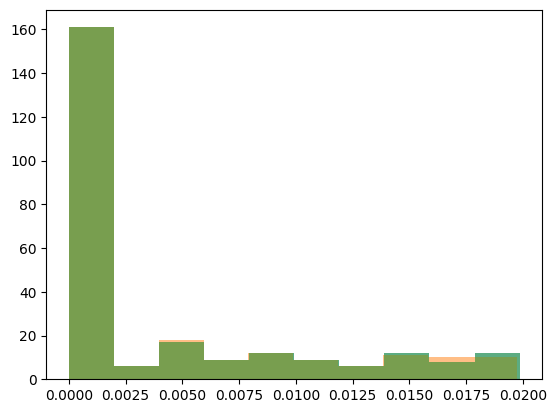

In [196]:
_ = plt.hist(df_test.fillna(0).loc[100], alpha=0.5)
_ = plt.hist(df_test_dirichlet.loc[100], alpha=0.5)
_ = plt.hist(df_test_cap.loc[100], alpha=0.5)

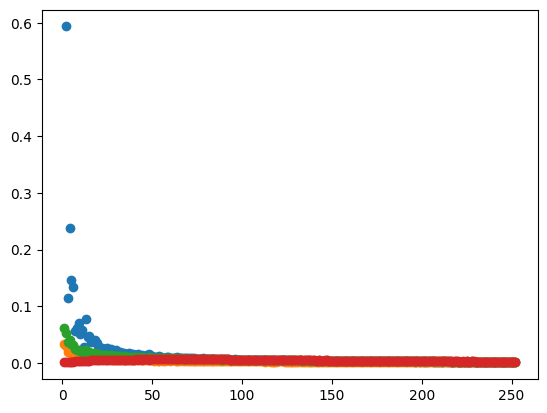

In [197]:
plt.scatter(df_test.index, df_test.std(axis=1))
plt.scatter(df_test.index, df_test_smoothed.std(axis=1))
plt.scatter(df_test.index, df_test_dirichlet.std(axis=1))
plt.scatter(df_test.index, df_test_cap.std(axis=1))

<BarContainer object of 252 artists>

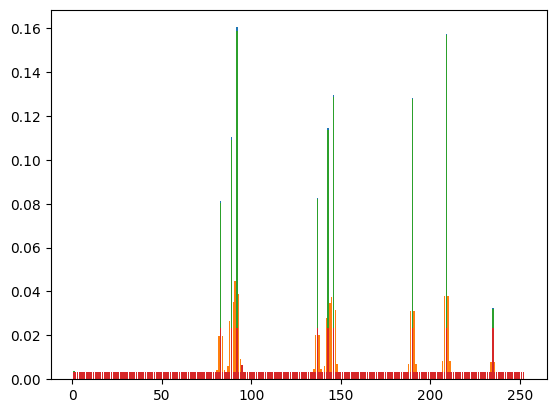

In [203]:
idx = 10
plt.bar(df_test.index, df_test.loc[idx])
plt.bar(df_test_smoothed.index, df_test_smoothed.loc[idx])
plt.bar(df_test_dirichlet.index, df_test_dirichlet.loc[idx])
plt.bar(df_test_cap.index, df_test_cap.loc[idx])

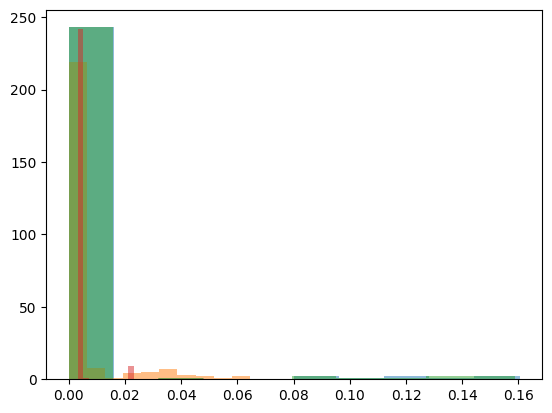

In [199]:
_ = plt.hist(df_test.fillna(0).loc[10], alpha=0.5)
_ = plt.hist(df_test_smoothed.fillna(0).loc[10], alpha=0.5)
_ = plt.hist(df_test_dirichlet.loc[10], alpha=0.5)
_ = plt.hist(df_test_cap.loc[10], alpha=0.5)

In [200]:
# df_dist_test_smoothed = uf.get_w1_distances(subfield_tree, df_test_smoothed)
# df_dist_test_dirichlet = uf.get_w1_distances(subfield_tree, df_test_dirichlet)
df_dist_test_cap = uf.get_w1_distances(subfield_tree, df_test_cap)

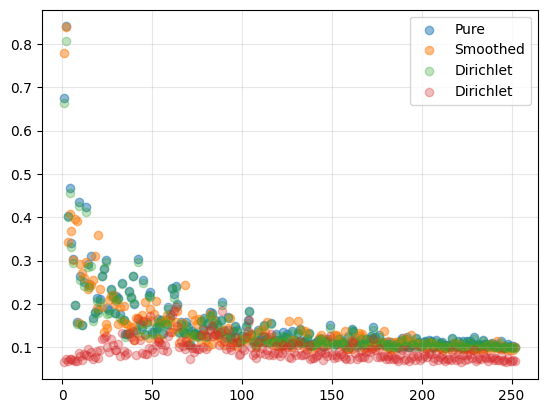

In [ ]:
plt.scatter(df_dist_test.index, df_dist_test.mean(), label="Pure", alpha=0.5)
plt.scatter(df_dist_test.index, df_dist_test_smoothed.mean(), label="Smoothed", alpha=0.5)
plt.scatter(df_dist_test.index, df_dist_test_dirichlet.mean(), label="Dirichlet", alpha=0.3)
plt.scatter(df_dist_test.index, df_dist_test_cap.mean(), label="Cap", alpha=0.3)

plt.legend()
plt.grid(alpha=0.3)

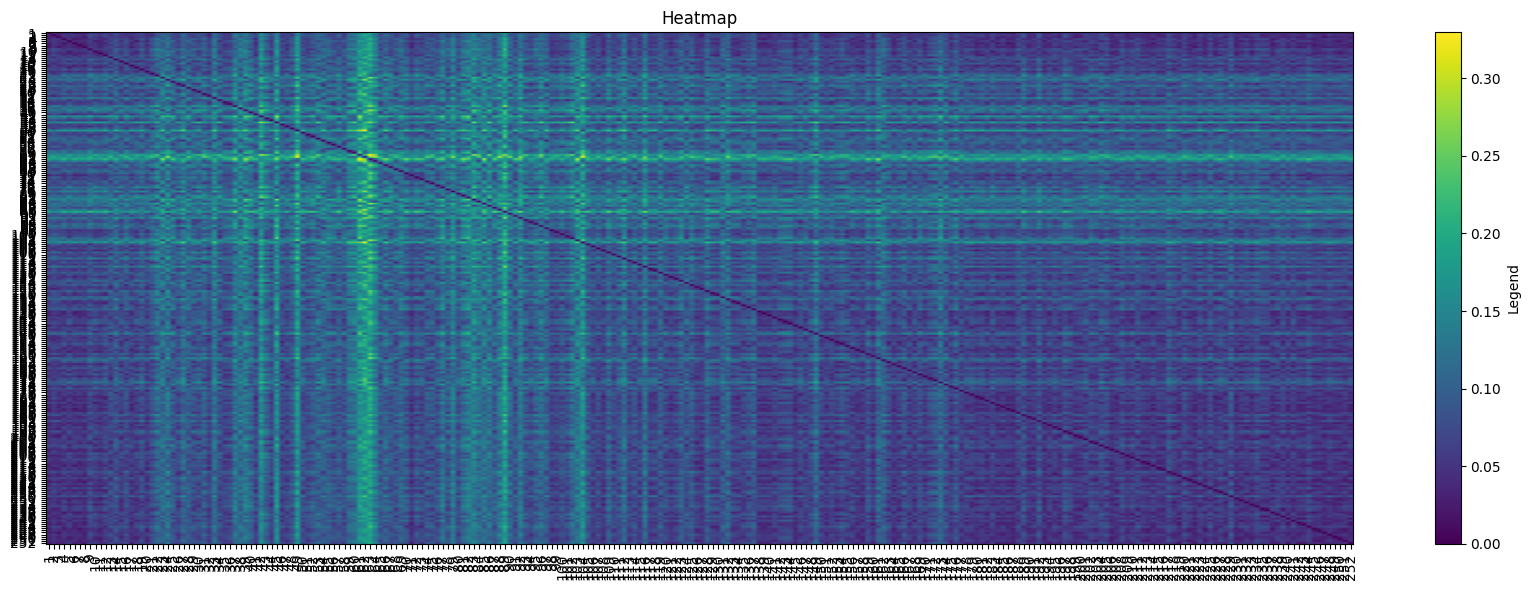

In [202]:
uf.plot_heatmap(
    df_dist_test_cap,
    x_labels = df_dist_test.columns,
    y_labels=df_dist_test.index
)

# Test distance big countries

In [3]:
def get_convergence_one_distribution(cs_country, w1_max, n_articles_array=None, n_samples=100, subfield_tree=None):
    subfields_list = cs_country.index
    prob_list = cs_country / cs_country.sum()

    if n_articles_array is None:
        n_articles_array = np.unique(np.logspace(0, np.log(cs_country.sum()), 50, base=np.exp(1)).astype(int))
    
    n_articles_samples = n_articles_array.shape[0]
    
    if subfield_tree is None:
        subfield_tree = uf.get_subfield_tree(uf.df_topics)

    rng = np.random.default_rng()

    # shape: (L, n_samples, K)
    all_counts = np.array([
        rng.multinomial(n, prob_list, size=n_samples)
        for n in n_articles_array
    ])

    # convert to probabilities
    all_probs = all_counts / all_counts.sum(axis=2, keepdims=True)

    dist_2d_array = np.empty((n_articles_samples, n_articles_samples))

    for i in tqdm(range(n_articles_samples)):
        for j in range(n_articles_samples):
            
            dists = np.full(n_samples, np.nan)
            
            for k in range(n_samples):
                _, _, dists[k] = (
                    uf.get_dist_w1_tree(
                        subfield_tree,
                        dict(zip(subfields_list, all_probs[i, k])),
                        dict(zip(subfields_list, all_probs[j, k])),
                    ) / w1_max
                )
            
            dist_2d_array[i, j] = np.median(dists)
    
    return pd.DataFrame(dist_2d_array, index=n_articles_array, columns=n_articles_array)

In [4]:
def get_convergence_two_distributions(cs_country1, cs_country2, w1_max, n_articles_array=None, n_samples=100, subfield_tree=None):
    subfields_list = cs_country1.index.union(cs_country2.index)

    prob_list_1 = cs_country1 / cs_country1.sum()
    prob_list_2 = cs_country2 / cs_country2.sum()

    if n_articles_array is None:
        total_max = max(cs_country1.sum(), cs_country2.sum())
        n_articles_array = np.unique(np.logspace(0, np.log10(total_max), 50).astype(int))
    
    n_articles_samples = n_articles_array.shape[0]
    
    if subfield_tree is None:
        subfield_tree = uf.get_subfield_tree(uf.df_topics)

    rng = np.random.default_rng()

    # shape: (L, n_samples, K)
    all_counts_1 = np.array([
        rng.multinomial(n, prob_list_1, size=n_samples)
        for n in n_articles_array
    ])

    all_counts_2 = np.array([
        rng.multinomial(n, prob_list_2, size=n_samples)
        for n in n_articles_array
    ])

    # convert to probabilities
    all_probs_1 = all_counts_1 / all_counts_1.sum(axis=2, keepdims=True)
    all_probs_2 = all_counts_2 / all_counts_2.sum(axis=2, keepdims=True)

    dist_2d_array = np.empty((n_articles_samples, n_articles_samples))

    for i in tqdm(range(n_articles_samples)):
        for j in range(n_articles_samples):
            
            dists = np.full(n_samples, np.nan)
            
            for k in range(n_samples):
                _, _, dists[k] = (
                    uf.get_dist_w1_tree(
                        subfield_tree,
                        dict(zip(subfields_list, all_probs_1[i, k])),
                        dict(zip(subfields_list, all_probs_2[j, k])),
                    ) / w1_max
                )
            
            dist_2d_array[i, j] = np.median(dists)
    
    return pd.DataFrame(dist_2d_array, index=n_articles_array, columns=n_articles_array)

In [6]:
def get_ks_p_val_two_distributions(cs_country1, cs_country2, n_articles_array=None, n_samples=100):

    prob_list_1 = cs_country1 / cs_country1.sum()
    prob_list_2 = cs_country2 / cs_country2.sum()

    if n_articles_array is None:
        total_max = max(cs_country1.sum(), cs_country2.sum())
        n_articles_array = np.unique(np.logspace(0, np.log10(total_max), 50).astype(int))
    
    n_articles_samples = n_articles_array.shape[0]

    rng = np.random.default_rng()

    # shape: (L, n_samples, K)
    all_counts_1 = np.array([
        rng.multinomial(n, prob_list_1, size=n_samples)
        for n in n_articles_array
    ])

    all_counts_2 = np.array([
        rng.multinomial(n, prob_list_2, size=n_samples)
        for n in n_articles_array
    ])

    # convert to probabilities
    all_probs_1 = all_counts_1 / all_counts_1.sum(axis=2, keepdims=True)
    all_probs_2 = all_counts_2 / all_counts_2.sum(axis=2, keepdims=True)

    dist_2d_array = np.empty((n_articles_samples, n_articles_samples))

    for i in tqdm(range(n_articles_samples)):
        for j in range(n_articles_samples):
            
            dists = np.full(n_samples, np.nan)
            
            for k in range(n_samples):
                _, dists[k] = (
                    stats.ks_2samp(all_probs_1[i, k, :], all_probs_2[j, k, :])
                )
            
            dist_2d_array[i, j] = np.median(dists)
    
    return pd.DataFrame(dist_2d_array, index=n_articles_array, columns=n_articles_array)

In [7]:
year = 2023
country = "CN"
mode = "individual"

In [8]:
df_cs = (
    pd.concat([
        pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0),
        pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0).sum(axis=0).to_frame("Global").T
    ])
    .fillna(0)
)

In [11]:
n_articles_array = np.unique(np.logspace(0, np.log10(df_cs.loc["Global"].sum()), 50).astype(int))
n_samples = 100
subfield_tree = uf.get_subfield_tree(uf.df_topics)
threshold = 0.01

subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})


In [10]:
df_conv = get_convergence_one_distribution(df_cs.loc["US"], w1_max, n_articles_array, n_samples, subfield_tree)

100%|██████████| 48/48 [00:57<00:00,  1.19s/it]


In [100]:
a, b = np.meshgrid(n_articles_array, n_articles_array)
c = np.maximum(a, b)
uf.plotly_heatmap(
    df_conv,
    # (df_conv > threshold).astype(int),
    # df_dist_2d.div(np.sqrt((a + b) / a / b)),
    x_labels=df_conv.columns.astype(str),
    y_labels=df_conv.columns.astype(str),
    title=f"Distance from n-article to m-article samples from the same distribution",
    line_height=10
)

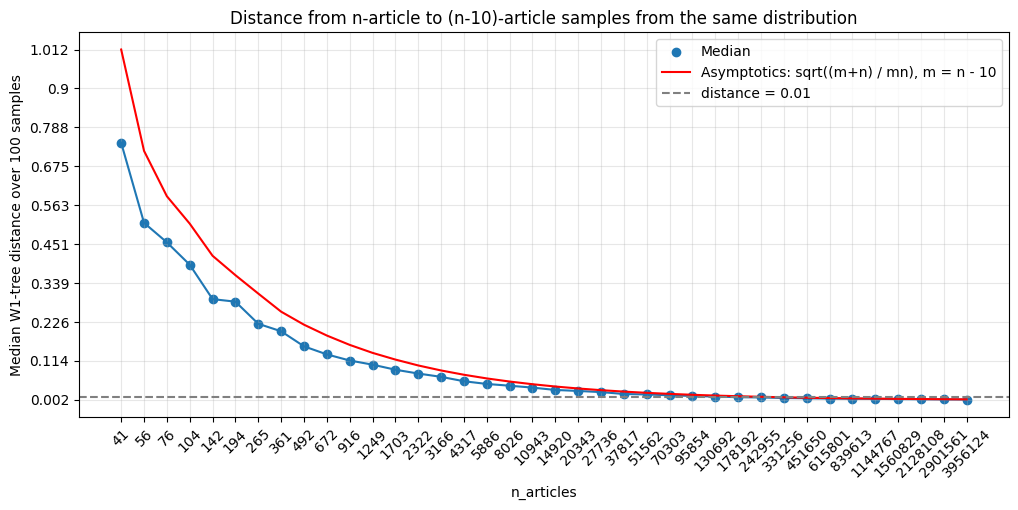

In [13]:
plt.subplots(figsize=(12, 5))

k_diag = 10
plt.scatter(df_conv.index.astype(str)[k_diag:], np.diag(df_conv.values, k_diag), label=f"Median")
plt.plot(df_conv.index.astype(str)[k_diag:], np.diag(df_conv.values, k_diag),)


asymp = np.sqrt((df_conv.index[k_diag:] + df_conv.index[:-k_diag]) / df_conv.index[k_diag:] / df_conv.index[:-k_diag])
plt.plot(df_conv.index.astype(str)[k_diag:], asymp, color="red", label=f"Asymptotics: sqrt((m+n) / mn), m = n - {k_diag}")
_ = plt.xticks(rotation=45)



min_val = np.diag(df_conv.values, k_diag).min()
max_val = asymp.max()
y_ticks = np.linspace(min_val, max_val, 10)
_ = plt.yticks(ticks = y_ticks, labels = np.round(y_ticks, 3))

threshold = 0.01
plt.axhline(threshold, color="grey", linestyle="--", label=f"distance = {threshold}")

plt.grid(alpha=0.3)
plt.title(f"Distance from n-article to (n-{k_diag})-article samples from the same distribution")
plt.xlabel("n_articles")
plt.ylabel(f"Median W1-tree distance over {n_samples} samples")
plt.legend()

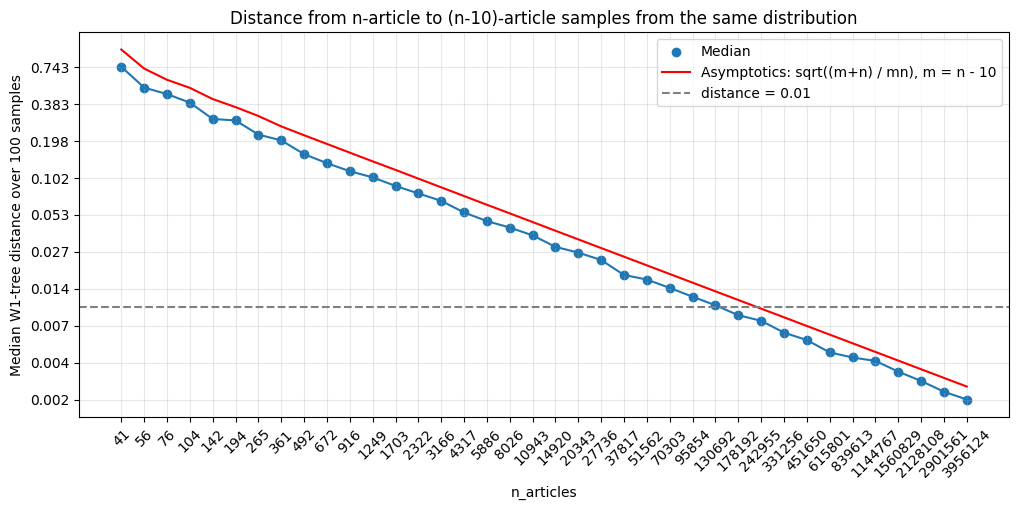

In [14]:
plt.subplots(figsize=(12, 5))

k_diag = 10
plt.scatter(df_conv.index.astype(str)[k_diag:], np.log(np.diag(df_conv.values, k_diag)), label=f"Median")
plt.plot(df_conv.index.astype(str)[k_diag:], np.log(np.diag(df_conv.values, k_diag)),)


asymp = np.sqrt((df_conv.index[k_diag:] + df_conv.index[:-k_diag]) / df_conv.index[k_diag:] / df_conv.index[:-k_diag])
plt.plot(df_conv.index.astype(str)[k_diag:], np.log(asymp), color="red", label=f"Asymptotics: sqrt((m+n) / mn), m = n - {k_diag}")
_ = plt.xticks(rotation=45)


min_val = np.log(np.diag(df_conv.values, k_diag)).min()
max_val = np.log(np.diag(df_conv.values, k_diag)).max()
y_ticks = np.linspace(min_val, max_val, 10)
_ = plt.yticks(ticks = y_ticks, labels = np.round(np.exp(y_ticks), 3))


threshold = 0.01
plt.axhline(np.log(threshold), color="grey", linestyle="--", label=f"distance = {threshold}")

plt.grid(alpha=0.3)
plt.title(f"Distance from n-article to (n-{k_diag})-article samples from the same distribution")
plt.xlabel("n_articles")
plt.ylabel(f"Median W1-tree distance over {n_samples} samples")
plt.legend()

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide

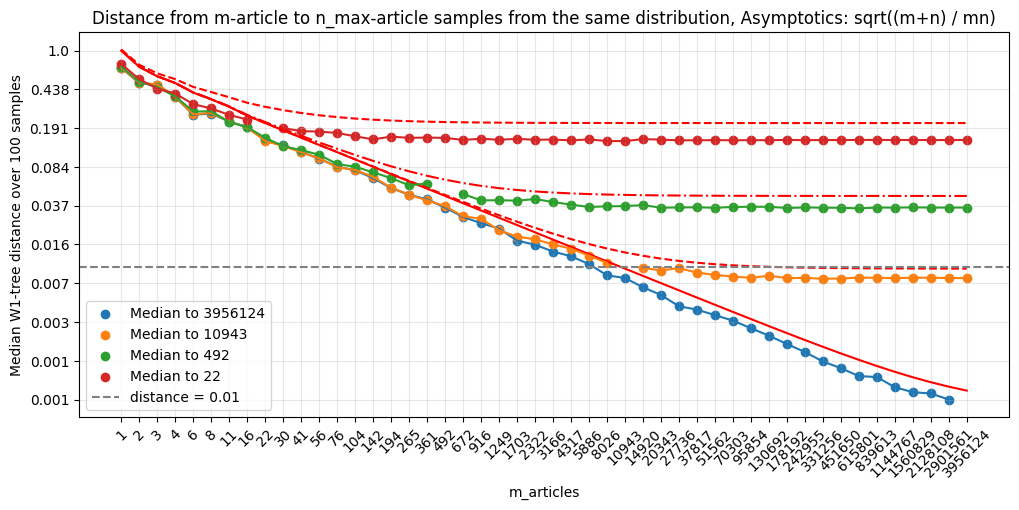

In [15]:
plt.subplots(figsize=(12, 5))

idx_list = [1, 20, 30, 40]
linestyle_list = ["-", "--", "-.", "--"]
for i, idx in enumerate(idx_list):
    plt.scatter(df_conv.index.astype(str), np.log(df_conv.iloc[-idx]), label=f"Median to {df_conv.index[-idx]}")
    plt.plot(df_conv.index.astype(str), np.log(df_conv.iloc[-idx]), )

    asymp = np.sqrt((df_conv.index + df_conv.index[-idx]) / df_conv.index / df_conv.index[-idx])
    plt.plot(df_conv.index.astype(str), np.log(asymp), color="red", linestyle=linestyle_list[i])
    _ = plt.xticks(rotation=45)

min_val = np.log(np.diag(df_conv.values, 1)).min()
max_val = np.log(np.diag(df_conv.values, 1)).max()
y_ticks = np.linspace(min_val, max_val, 10)
_ = plt.yticks(ticks = y_ticks, labels = np.round(np.exp(y_ticks), 3))

threshold = 0.01
plt.axhline(np.log(threshold), color="grey", linestyle="--", label=f"distance = {threshold}")

plt.grid(alpha=0.3)
plt.title(f"Distance from m-article to n_max-article samples from the same distribution, Asymptotics: sqrt((m+n) / mn)")
plt.xlabel("m_articles")
plt.ylabel(f"Median W1-tree distance over {n_samples} samples")
plt.legend()
plt.show()

In [16]:
country1 = "US"
country2 = "CA"
df_conv_2d = get_convergence_two_distributions(df_cs.loc["US"], df_cs.loc["CN"], w1_max, n_articles_array, n_samples, subfield_tree)

100%|██████████| 48/48 [00:57<00:00,  1.20s/it]


In [17]:
country1 = "US"
country2 = "CA"
df_conv_2d_dict = {}

country2_list = ["US", "CN", "ID", "CA"]
for country2 in country2_list:
    df_conv_2d_dict[country2] = get_convergence_two_distributions(df_cs.loc["US"], df_cs.loc[country2], w1_max, n_articles_array, n_samples, subfield_tree)

100%|██████████| 48/48 [00:58<00:00,  1.21s/it]


In [18]:
country2 = "CN"
a, b = np.meshgrid(n_articles_array, n_articles_array)
c = np.maximum(a, b)
uf.plotly_heatmap(
    df_conv_2d_dict[country2],
    # ((df_conv_2d.sub(df_conv_2d.iloc[-1, -1])) > threshold).astype(int),
    # df_dist_2d.div(np.sqrt((a + b) / a / b)),
    x_labels=df_conv_2d.columns.astype(str),
    y_labels=df_conv_2d.columns.astype(str),
    title=f"Distance from n-article to m-article samples: {country1} vs {country2}",
    line_height=10
)

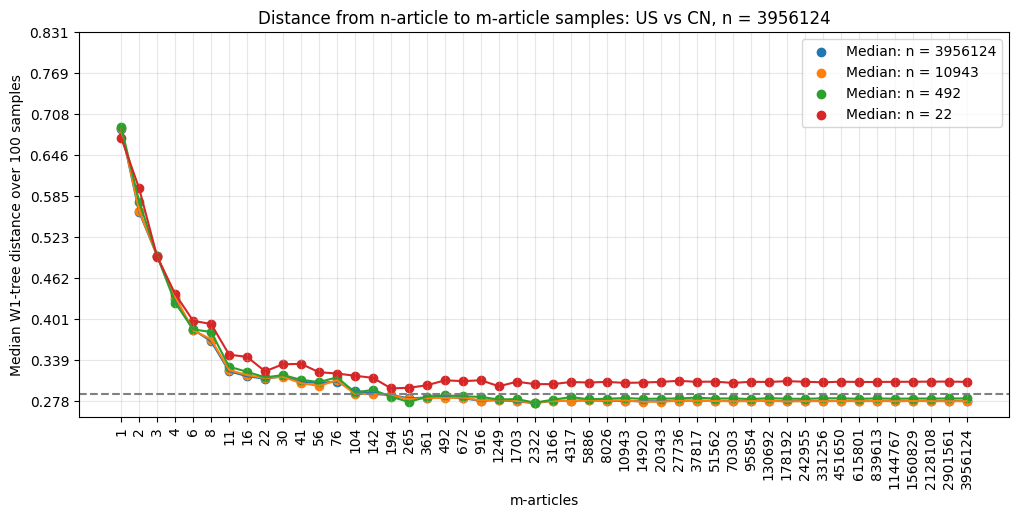

In [19]:
plt.subplots(figsize=(12, 5))

for i, idx in enumerate(idx_list):
    plt.scatter(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-idx], label=f"Median: n = {df_conv_2d.index[-idx]}")
    plt.plot(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-idx],)

min_val = np.diag(df_conv_2d.values, k_diag).min()
max_val = np.diag(df_conv_2d.values, k_diag).max()
y_ticks = np.linspace(min_val, max_val, 10)
_ = plt.yticks(ticks = y_ticks, labels = np.round(y_ticks, 3))
_ = plt.xticks(rotation=90)

plt.axhline(df_conv_2d.iloc[-1, -1] + threshold, color="grey", linestyle = "--")

plt.grid(alpha=0.3)
plt.title(f"Distance from n-article to m-article samples: {country1} vs {country2}, n = {df_conv_2d.index[-1]}")
plt.xlabel("m-articles")
plt.ylabel(f"Median W1-tree distance over {n_samples} samples")
plt.legend()

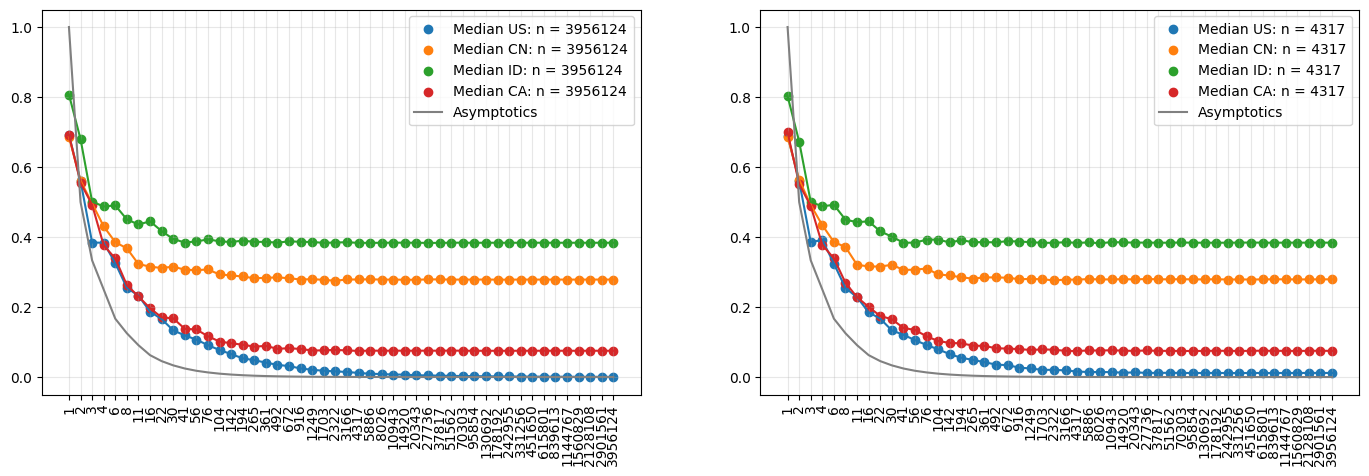

In [34]:
fig, (ax1, ax2) = plt.subplots(figsize=(17, 5), nrows=1, ncols=2)
for country2 in country2_list:
    ax1.scatter(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-1], label=f"Median {country2}: n = {df_conv_2d.index[-1]}")
    ax1.plot(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-1],)

ax1.plot(df_conv_2d.index.astype(str), 1 / df_conv_2d.index, color="grey", label="Asymptotics")
ax1.legend()
ax1.tick_params(axis='x', rotation=90)
ax1.grid(alpha=0.3)
idx= 23
for country2 in country2_list:
    ax2.scatter(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-idx], label=f"Median {country2}: n = {df_conv_2d.index[-idx]}")
    ax2.plot(df_conv_2d.index.astype(str), df_conv_2d_dict[country2].iloc[-idx],)

ax2.plot(df_conv_2d.index.astype(str), 1 / df_conv_2d.index, color="grey", label="Asymptotics")
ax2.legend()
_ = plt.xticks(rotation=90)
ax2.grid(alpha=0.3)

In [21]:
df_ks_2d_dict = {}

for country2 in country2_list:
    df_ks_2d_dict[country2] = get_ks_p_val_two_distributions(df_cs.loc[country1], df_cs.loc[country2], n_articles_array, n_samples)

  0%|          | 0/48 [00:00<?, ?it/s]/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.

100%|██████████| 48/48 [00:32<00:00,  1.46it/s]


In [101]:
country2 = "CN"
uf.plotly_heatmap(
    df_ks_2d_dict[country2],
    # ((df_conv_2d.sub(df_conv_2d.iloc[-1, -1])) > threshold).astype(int),
    # df_dist_2d.div(np.sqrt((a + b) / a / b)),
    x_labels=df_ks_2d_dict[country2].columns.astype(str),
    y_labels=df_ks_2d_dict[country2].columns.astype(str),
    title=f"KS p-value (same distribution): {country1} vs {country2}",
    line_height=10
)

In [102]:
cap_articles = 1000

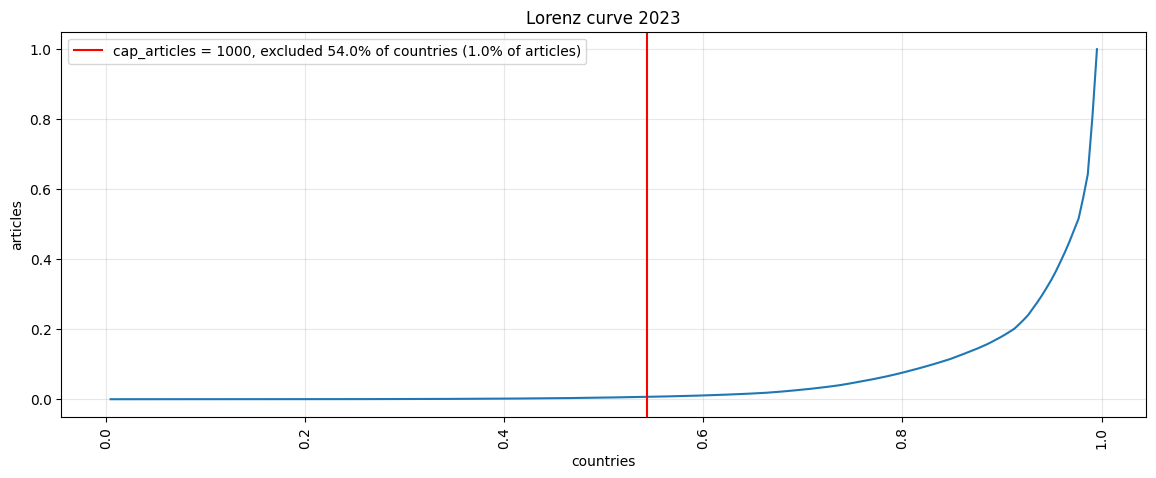

In [103]:
## Cutoff at 5000
total_prod = df_cs.sum(axis=1).drop(index="Global").sort_values().to_frame("total")
first = total_prod.query("total >= @cap_articles").index[0]
excluded = np.round(total_prod.query("total < @cap_articles").total.sum() / total_prod.total.sum() * 100)
plt.subplots(figsize=(14, 5))
plt.plot(np.arange(1, len(total_prod.index)+1) / (len(total_prod.index)+1), total_prod.cumsum() / total_prod.cumsum().iloc[-1])
plt.axvline(total_prod.index.to_list().index(first) / (len(total_prod.index)+1), color="red",
            label = f"cap_articles = {cap_articles}, excluded {np.round(total_prod.index.to_list().index(first) / (len(total_prod.index)+1), 2) * 100}% of countries ({excluded}% of articles)")
_ = plt.xticks(rotation=90)
plt.xlabel("countries")
plt.ylabel("articles")
plt.legend()
plt.grid(alpha=0.3)
_ = plt.title(f"Lorenz curve {year}")

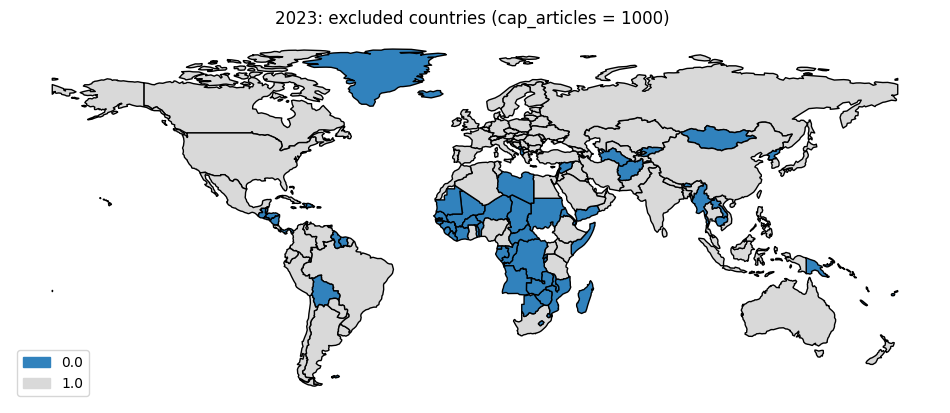

In [105]:
total_prod_map = (
    total_prod
    .assign(passed=lambda df: (df.total >= cap_articles).astype(int))
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2", how="left")
)
_ = uf.plot_map_discrete(total_prod_map, column="passed", title=f"{year}: excluded countries (cap_articles = {cap_articles})")

# Test if distributions are distinguishable

In [111]:
country1 = "GE"
df_baseline1 = (
    pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)
    .loc[country1]
    .fillna(0)
    .astype(int)
    .to_frame("baseline")
    .reset_index(names="subfield_id")
    .assign(
        subfield_id_str=lambda df: df.subfield_id.astype(str),
        baseline_prob = lambda df: df.baseline / df.baseline.sum()
    )
    .drop(columns="subfield_id")
    .rename(columns={"subfield_id_str": "subfield_id"})
)

In [112]:
country2 = "CN"
df_baseline2 = (
    pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)
    .loc[country2]
    .fillna(0)
    .astype(int)
    .to_frame("baseline")
    .reset_index(names="subfield_id")
    .assign(
        subfield_id_str=lambda df: df.subfield_id.astype(str),
        baseline_prob = lambda df: df.baseline / df.baseline.sum()
    )
    .drop(columns="subfield_id")
    .rename(columns={"subfield_id_str": "subfield_id"})
)

In [115]:
n_samples = 100

rng = np.random.default_rng()

n_articles = 1000000
m_articles = 10000

# shape: (L, n_samples, K)
all_counts1 = np.array([
    rng.multinomial(m_articles, df_baseline1.baseline_prob.values, size=n_samples)
])
all_probs1 = all_counts1 / all_counts1.sum(axis=2, keepdims=True)

all_counts2 = np.array([
    rng.multinomial(n_articles, df_baseline2.baseline_prob.values, size=n_samples)
])
all_probs2 = all_counts2 / all_counts2.sum(axis=2, keepdims=True)

stat, p_val = stats.ks_2samp(all_probs1[0, 10, :], all_probs2[0, 10, :], method="exact")

alpha= 0.05

result = "same" if p_val >= alpha else "different"
("Hypothesis 'same distribution' is rejected: ", p_val < alpha)

("Hypothesis 'same distribution' is rejected: ", np.True_)

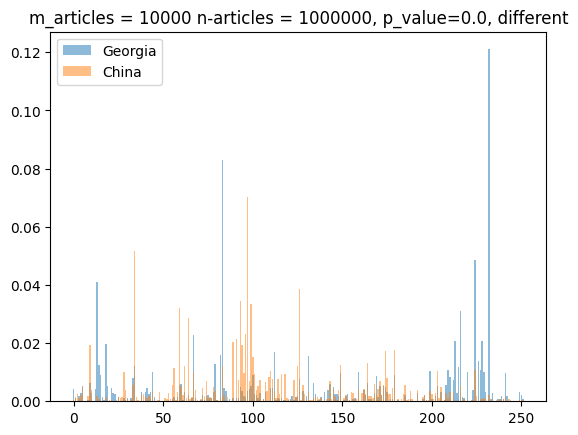

In [116]:
plt.bar(range(all_probs1.shape[2]), all_probs1[0, 0, :], alpha=0.5, label=uf.id2name_country[country1])
plt.bar(range(all_probs2.shape[2]), all_probs2[0, 1, :], alpha=0.5, label=uf.id2name_country[country2])
plt.title(f"m_articles = {m_articles} n-articles = {n_articles}, p_value={round(p_val, 2)}, {result}")
plt.legend()